In [ ]:
from langchain.messages import HumanMessage,SystemMessage
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph,START,END,MessagesState
from langchain.tools import tool
from typing import Literal,Annotated
from langchain_tavily import TavilySearch
from langgraph.prebuilt import ToolNode
from langgraph.types import Command

In [2]:
class ContentState(MessagesState):
    topic:str

In [3]:
load_dotenv()
SERPAPI_KEY=os.getenv("SERPAPI_KEY")

In [4]:
model=ChatGroq(model="llama-3.1-8b-instant")
versatile_model=ChatGroq(model="llama-3.3-70b-versatile")

In [5]:
from datetime import datetime
@tool
def search_tool(query:str,limit:int):
    """This tool is used to search content from the internet."""
    print("CALLED SEARCH TOOL WITH QUERY:",query)
    search_agent=TavilySearch()
    res=search_agent.invoke({"query":query})["results"][:limit]
    response=""
    for data in res:
        response+=data["content"]+"\n"
    return response
@tool
def get_date_time():
    """This tool returns current date and time"""
    return datetime.now()

In [6]:
def research_node(state:ContentState):
    system_prompt="""You are the Research Agent. Use the `search_tool` strictly ONCE to gather relevant information 
        about the given topic. Call the tool, analyze the results, and provide a clear, 
        synthesized summary of facts for the Writer team. Do NOT make multiple parallel tool calls.
        while calling the `search_tool` remember to pass limit in int and query as a string. You are also given with the `get_date_time` tool to find current date and time. DO not assume any dates on your own use tool to get current date and time"""
    print("CALLED RESEARCH NODE",)
    researcher_model=model.bind_tools([search_tool,get_date_time])
    messages=[SystemMessage(system_prompt),HumanMessage("topic:",state['topic'])]+state['messages']
    res=researcher_model.invoke(messages)
    return {"messages":[res]}

def check_tool(state:ContentState):
    """Determine whether to use a tool or end the subgraph."""

    last_message=state['messages'][-1]
    if(last_message.tool_calls):
        return "tool_node"
    return END

In [7]:
research_graph=StateGraph(ContentState)
research_graph.add_node("research_node",research_node)
research_graph.add_node("tool_node",ToolNode([search_tool,get_date_time]))

research_graph.add_edge(START,"research_node")
research_graph.add_conditional_edges("research_node",check_tool,{"tool_node":"tool_node",END:END})
research_graph.add_edge("tool_node","research_node")

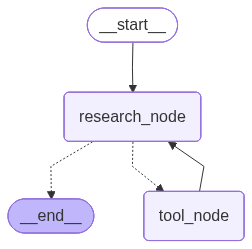

In [8]:
researchers=research_graph.compile()
researchers

In [9]:
# researchers.invoke({"topic":"What is the today's date"})

In [10]:
import os
import smtplib

from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
from email.mime.base import MIMEBase

from email import encoders



@tool
def send_email_tool(
    to_email: str,
    subject: str,
    body: str,
    file_name: str
):
    """
    Send an email with a file attachment.
    """

    try:
        sender_email = os.getenv("EMAIL_ADDRESS")
        sender_password = os.getenv("EMAIL_PASSWORD")

        # Create email
        message = MIMEMultipart()

        message["From"] = sender_email
        message["To"] = to_email
        message["Subject"] = subject

        # Email body
        message.attach(MIMEText(body, "plain"))

        # Check file exists
        if not os.path.exists(file_name):
            return {
                "status": "error",
                "message": f"File '{file_name}' does not exist."
            }

        # Attach file
        with open(file_name, "rb") as attachment:

            part = MIMEBase("application", "octet-stream")

            part.set_payload(attachment.read())

        encoders.encode_base64(part)

        part.add_header(
            "Content-Disposition",
            f"attachment; filename={os.path.basename(file_name)}"
        )

        message.attach(part)

        # Send email
        with smtplib.SMTP("smtp.gmail.com", 587) as server:

            server.starttls()

            server.login(sender_email, sender_password)

            server.send_message(message)

        return {
            "status": "success",
            "message": f"Email with attachment sent to {to_email}"
        }

    except Exception as e:

        return {
            "status": "error",
            "message": str(e)
        }

In [11]:
@tool
def write_file_tool(file_name: str, content: str):
    """
    Create a new file or append content to an existing file.
    """

    print("WRITER NODE EXECUTED")
    

    try:
        with open(file_name, "w", encoding="utf-8") as file:
            file.write(content + "\n")
        print(f"file {file_name} saved successfully!")
        return {
            "status": "success",
            "message": f"Content saved successfully in {file_name}"
        }

    except Exception as e:
        return {
            "status": "error",
            "message": str(e)
        }


@tool
def read_file_tool(
    file_name: str,
    end: Annotated[int, "Line number to read until"],
    start: Annotated[int, "Line number to start reading from"] = 0
):
    """
    Read content from an existing file.
    """

    print("READ NODE EXECUTED")

    try:
        if not os.path.exists(file_name):
            return {
                "status": "error",
                "message": f"File '{file_name}' does not exist.",
                "content": []
            }

        with open(file_name, "r", encoding="utf-8") as file:
            lines = file.readlines()

        content = lines[start:end]

        return {
            "status": "success",
            "message": f"File {file_name} read successfully",
            "content": content
        }

    except Exception as e:
        return {
            "status": "error",
            "message": str(e),
            "content": []
        }


@tool
def edit_file_tool(
    content: Annotated[str, "Content to replace existing lines with"],
    file_name: str,
    end: Annotated[int, "Ending line number"],
    start: Annotated[int, "Starting line number"] = 0
):
    """
    Edit specific lines in an existing file.
    """

    print("EDIT NODE EXECUTED")

    try:
        if not os.path.exists(file_name):
            
            return {
                "status": "error",
                "message": f"File '{file_name}' does not exist."
            }

        with open(file_name, "r", encoding="utf-8") as file:
            file_data = file.readlines()

        # Ensure newline
        replacement = content + "\n"

        updated_data = (
            file_data[:start]
            + [replacement]
            + file_data[end:]
        )

        with open(file_name, "w", encoding="utf-8") as file:
            file.writelines(updated_data)
        
        print(f"file {file_name} edited and saved successfully!")
        return {
            "status": "success",
            "message": f"Content edited successfully in {file_name}"
        }

    except Exception as e:
        return {
            "status": "error",
            "message": str(e)
        }


writer_tools = [write_file_tool, read_file_tool, edit_file_tool,send_email_tool]

In [12]:
def writer_node(state:ContentState):
    system_prompt="""You are the Writer Agent. Use the facts provided by the Research team in the conversation history
        to write an engaging, well-formatted blog post or article. Researcher team search the content for you
        RULES:
        1. Write the final article by fully invoking the `write_file_tool` ONCE.
        2. Do NOT write line-by-line.
        3. You must provide a valid `file_name` taking inspiration from the topic with .txt extension eg.: `topic.txt`, `news.txt`, `updates.txt`, etc.
        4. You are given with `write_file_tool`, `read_file_tool` and `edit_file_tool` to make changes in the file.
        5. You are also given `send_email_tool` to send an email to the email mentioned. If user did not mention in its query skip the email. Send email only when the file is saved .
        
        You only have these tools:
        `write_file_tool`: Create and make changes in the file
        `read_file_tool`: Read content of the file
        `edit_file_tool`: Make changes in the specific content in the file
        `send_email_tool`: To send an email to the person's mail id.
        
        RULES:
        Avoid excessive quotation marks.
        Summarize instead of copying exact sentences.
        Do not include escaped quotes or escape characters.
        DO NOT CALL ANY OTHER TOOL THAN PROVIDED.
        Make sure the file is properly saved.
        DO not send email if you do not have an email address.
        """
    
    print("CALLED WRITER NODE",)

    messages=[SystemMessage(system_prompt),HumanMessage(f"topic:{state['topic']}. Please draft the file based on the previous context.")]+state['messages']
    writer_model=model.bind_tools(writer_tools)
    res=writer_model.invoke(messages)
    return{"messages":[res]}
def check_writer_tool(state:ContentState):
    """Determine whether to use a tool or end the subgraph."""
    last_message=state['messages'][-1]
    if(last_message.tool_calls):
        return "tool_node"
    return END

In [13]:
writer_state_graph=StateGraph(ContentState)
writer_state_graph.add_node("writer_node",writer_node)
writer_state_graph.add_node("tool_node",ToolNode(writer_tools))

writer_state_graph.add_edge(START,'writer_node')
writer_state_graph.add_conditional_edges("writer_node",check_writer_tool,{"tool_node":"tool_node",END:END})
writer_state_graph.add_edge("tool_node","writer_node")

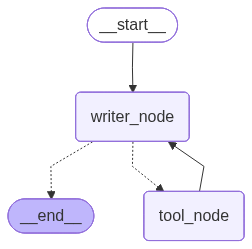

In [14]:
writers=writer_state_graph.compile()
writers

In [15]:
from pydantic import BaseModel
class SupervisorRouter(BaseModel):
    next: Literal["research_team", "writer_team", "FINISH"]
    instruction:str

In [16]:
def supervisor_node(state:ContentState):
    system_prompt="""
    You are the Workflow Supervisor managing a Content Creation Process.
        You have access to two teams:
        1. 'research_team': Search the web and gather information from web.It can also Identify current date and time for you.
        2. 'writer_team': Write the gathered facts into an article file.\n
        
        WORKFLOW RULES:
        1. If there are no search results in the conversation history, route to 'research_team'.
        2. If 'research_team' has already provided the search facts/summary, you MUST route to 'writer_team'. Do NOT route back to 'research_team'.
        3. If 'writer_team' has confirmed the file is saved, route to 'FINISH'.
        4. Do not review files unnecessarily, once file is written by the writer team just go to finish 
        
        Do not get stuck in a loop. Moving forward to the next team is strictly required.
        Also write the complete instruction so that the team could understand what it needs to do
    """
    
    print("CALLED SUPERVISOR NODE",)

    messages=[SystemMessage(system_prompt),HumanMessage(content="topic:"+state["topic"])]+state["messages"]
    supervisor_model=versatile_model.with_structured_output(SupervisorRouter)

    res=supervisor_model.invoke(messages)
    print(f"\n📌 [Supervisor Decision] Routing to 👉 {res.next}")
    print(f"💬 [Supervisor Context] {res.instruction}\n")
    
    if(res.next=="FINISH"):
        return Command(goto=END)
    return Command(goto=res.next,update={"messages":SystemMessage("Supervisor says:"+res.instruction)})

In [ ]:
supervisor_graph=StateGraph(ContentState)
supervisor_graph.add_node("supervisor_node",supervisor_node)
supervisor_graph.add_node("research_team",researchers)
supervisor_graph.add_node("writer_team",writers)
supervisor_graph.add_node("tool",ToolNode([get_date_time]))


supervisor_graph.add_edge(START,"supervisor_node")
supervisor_graph.add_edge("research_team","supervisor_node")
supervisor_graph.add_edge("writer_team","supervisor_node")


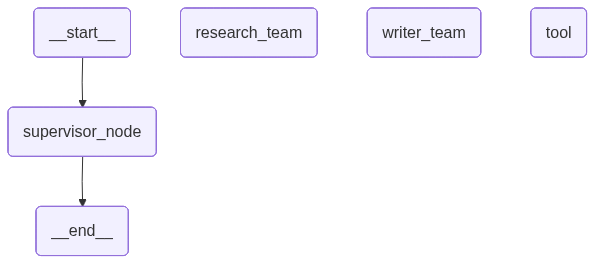

In [18]:
workflow=supervisor_graph.compile()
workflow

In [19]:
workflow.invoke({"topic":"Find me the next shreya ghoshal's concert date"})
# res=workflow.invoke({"topic":""})


CALLED SUPERVISOR NODE

📌 [Supervisor Decision] Routing to 👉 research_team
💬 [Supervisor Context] Find the next Shreya Ghoshal concert date and provide the details of the event including date, time, location, and any other relevant information

CALLED RESEARCH NODE
CALLED SEARCH TOOL WITH QUERY: Shreya Ghoshal upcoming concert dates
CALLED RESEARCH NODE
CALLED SUPERVISOR NODE

📌 [Supervisor Decision] Routing to 👉 writer_team
💬 [Supervisor Context] Write an article about the next Shreya Ghoshal concert dates, including the details of the event such as date, time, location, and any other relevant information. Use the search results provided to gather the necessary information.

CALLED WRITER NODE
WRITER NODE EXECUTED
file upcoming_shreya_ghoshal_concerts.txt saved successfully!
CALLED WRITER NODE
CALLED SUPERVISOR NODE

📌 [Supervisor Decision] Routing to 👉 FINISH
💬 [Supervisor Context] The task is complete. The article about Shreya Ghoshal's concert dates has been written and saved in a 

{'messages': [SystemMessage(content='Supervisor says:Find the next Shreya Ghoshal concert date and provide the details of the event including date, time, location, and any other relevant information', additional_kwargs={}, response_metadata={}, id='ab85d7ed-9697-426c-aaa2-f39767c58b44'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'pz7azmdek', 'function': {'arguments': '{}', 'name': 'get_date_time'}, 'type': 'function'}, {'id': 'm4h0nehxd', 'function': {'arguments': '{"limit":5,"query":"Shreya Ghoshal upcoming concert dates"}', 'name': 'search_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 435, 'total_tokens': 470, 'completion_time': 0.357611142, 'completion_tokens_details': None, 'prompt_time': 0.035087817, 'prompt_tokens_details': None, 'queue_time': 0.053150463, 'total_time': 0.392698959}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_